Total rows: 129

Status:
status
OK         78
SKIPPED    49
FAILED      2
Name: count, dtype: int64

Successful fits: 78
Valid fits: 78

Theta [mas]
count    78.000000
mean      1.829907
std       4.411079
min       0.010874
25%       0.114113
50%       0.682380
75%       2.007488
max      35.881553
Name: theta_mas, dtype: float64

Tb [K]
count    7.800000e+01
mean     4.329063e+12
std      1.132465e+13
min      2.929823e+07
25%      5.359447e+10
50%      3.173203e+11
75%      3.462335e+12
max      6.822589e+13
Name: Tb_K, dtype: float64


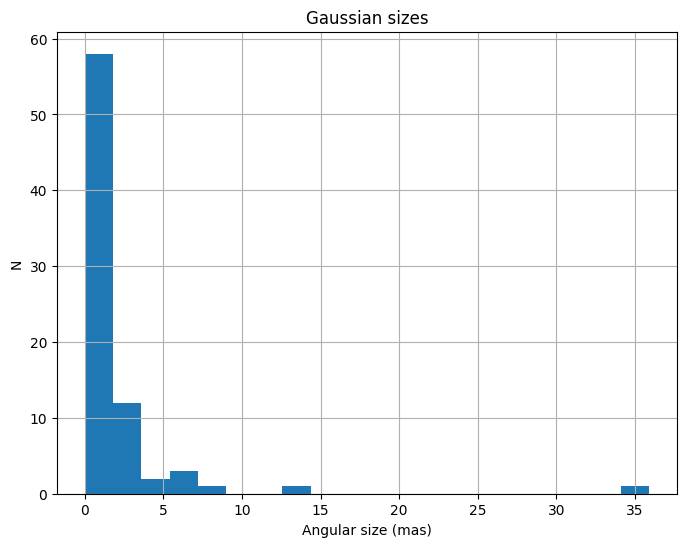

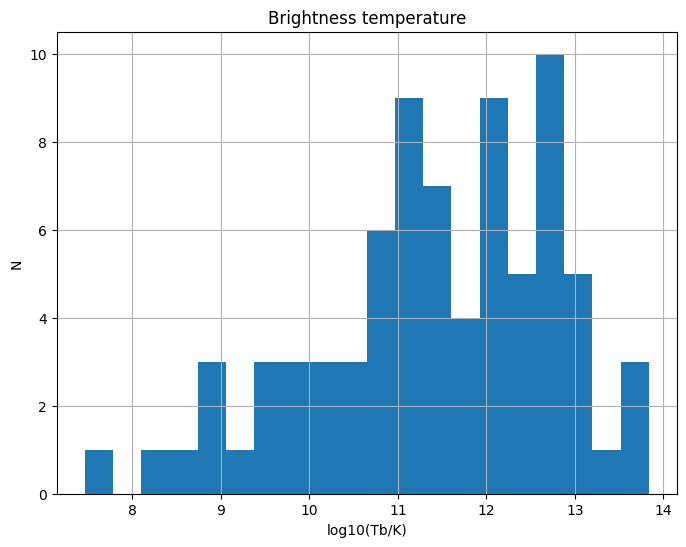

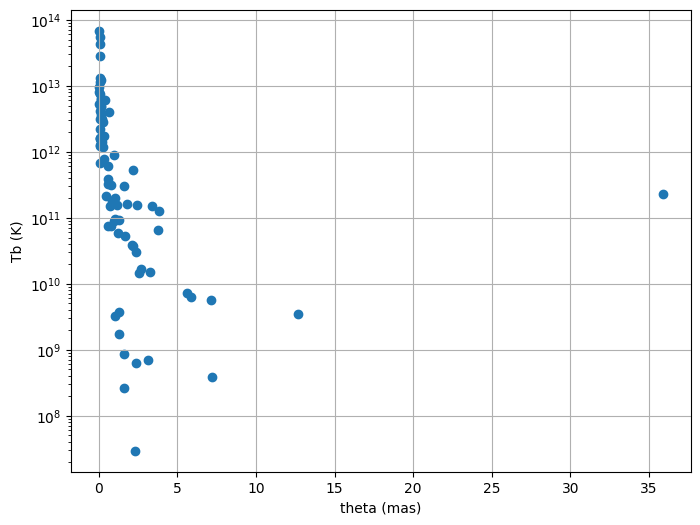


By band
      theta_mas          Tb_K
band                         
C      0.610263  3.159914e+11
K      0.050000  9.433275e+11
L      1.779251  3.041017e+11

By mode
             theta_mas          Tb_K
mode                                
GVLBI         1.947454  1.568476e+10
RADIOASTRON   0.421146  7.197229e+11

Smallest sizes


,session,date,band,theta_mas,theta_mas_err,Tb_K
74,RAKS12SY,20160329T010000,K,0.010874,3.986381,9.648455e+12
46,RAKS08JQ,20141214T080000,K,0.011912,3.944949,6.822589e+13
70,RAKS12LF,20160108T050000,K,0.019649,9.844477,7.982139e+12
36,RAKS01XF,20140327T000000,K,0.030085,1.385877,5.295099e+12
39,RAKS01ZM,20140417T235130,K,0.050000,0.285363,1.575509e+12
76,RAKS12UA,20160407T225200,K,0.050000,0.243403,1.620769e+12
4,RAES03FW,20121119T081000,C,0.050000,11832.750879,4.299542e+13
21,RAES03RL,20130421T185200,K,0.050000,0.407570,1.596092e+12
95,RAKS16CU,20161111T090000,K,0.050000,143531.407762,1.217494e+12
98,RAKS16FU,20161209T070000,C,0.050000,19107.362221,2.866500e+13



Highest Tb


,session,date,band,theta_mas,theta_mas_err,Tb_K
46,RAKS08JQ,20141214T080000,K,0.011912,3.944949,6.822589e+13
56,RAKS08UR,20150403T220000,C,0.077013,5.593099,5.502597e+13
4,RAES03FW,20121119T081000,C,0.050000,11832.750879,4.299542e+13
98,RAKS16FU,20161209T070000,C,0.050000,19107.362221,2.866500e+13
51,RAKS08TO,20150327T001000,C,0.090678,3.779929,1.309173e+13
14,RAES03Q,20120405T170000,C,0.128856,0.475556,1.222481e+13
120,RAKS18OX,20180311T160000,C,0.096191,0.431623,1.145426e+13
74,RAKS12SY,20160329T010000,K,0.010874,3.986381,9.648455e+12
70,RAKS12LF,20160108T050000,K,0.019649,9.844477,7.982139e+12
37,RAKS01XX,20140403T010000,C,0.094639,4.120599,7.453633e+12


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV = "gaussian_fits/gaussian_fit_log.csv"

df = pd.read_csv(CSV)

print("Total rows:", len(df))

print("\nStatus:")
print(df["status"].value_counts())

# ----------------------------------------
# только успешные фиты
# ----------------------------------------

ok = df[df.status == "OK"].copy()

print("\nSuccessful fits:", len(ok))

# ----------------------------------------
# очистка
# ----------------------------------------

ok = ok.replace(
    [np.inf, -np.inf],
    np.nan
)

ok = ok.dropna(
    subset=[
        "theta_mas",
        "Tb_K"
    ]
)

print("Valid fits:", len(ok))

# ----------------------------------------
# статистика
# ----------------------------------------

print("\nTheta [mas]")

print(
    ok["theta_mas"].describe()
)

print("\nTb [K]")

print(
    ok["Tb_K"].describe()
)

# ----------------------------------------
# histogram theta
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    ok["theta_mas"],
    bins=20
)

plt.xlabel("Angular size (mas)")
plt.ylabel("N")

plt.title("Gaussian sizes")

plt.grid()

plt.show()

# ----------------------------------------
# histogram Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.hist(
    np.log10(ok["Tb_K"]),
    bins=20
)

plt.xlabel("log10(Tb/K)")
plt.ylabel("N")

plt.title("Brightness temperature")

plt.grid()

plt.show()

# ----------------------------------------
# theta vs Tb
# ----------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    ok["theta_mas"],
    ok["Tb_K"]
)

plt.yscale("log")

plt.xlabel("theta (mas)")
plt.ylabel("Tb (K)")

plt.grid()

plt.show()

# ----------------------------------------
# by band
# ----------------------------------------

print("\nBy band")

print(
    ok.groupby("band")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# by mode
# ----------------------------------------

print("\nBy mode")

print(
    ok.groupby("mode")[
        ["theta_mas", "Tb_K"]
    ].median()
)

# ----------------------------------------
# compact epochs
# ----------------------------------------

print("\nSmallest sizes")

display(

    ok.sort_values(
        "theta_mas"
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",  # добавлено
            "Tb_K"
        ]
    ].head(20)

)

# ----------------------------------------
# hottest epochs
# ----------------------------------------

print("\nHighest Tb")

display(

    ok.sort_values(
        "Tb_K",
        ascending=False
    )[
        [
            "session",
            "date",
            "band",
            "theta_mas",
            "theta_mas_err",
            "Tb_K"
        ]
    ].head(20)

)

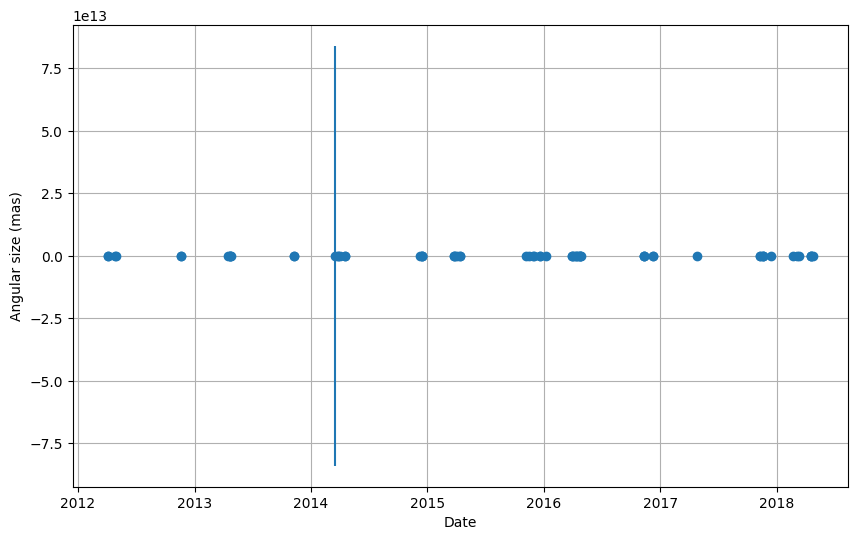

In [19]:
ra = ok[
    ok["mode"] == "RADIOASTRON"
]

plt.figure(figsize=(10,6))

plt.errorbar(
    pd.to_datetime(
        ra["date"].str[:8],  # берем только первые 8 символов (дату)
        format="%Y%m%d"
    ),
    ra["theta_mas"],
    yerr=ra["theta_mas_err"],
    fmt="o"
)

plt.xlabel("Date")
plt.ylabel("Angular size (mas)")
plt.grid()

plt.show()